<h1 style="text-align:center;">Python Data Analysis Assignment</h1>

<h2 style="text-align:left;">Contents</h2>

1. [Importing Necessary Files](#1)
2. [Reading and Storing Values in DataFrames](#2)
3. [Analyzing DataFrames using describe(), info() and head() methods](#3)
4. [Task A - Preprocessing](#4)
    - [User Data Cleaning](#4.1)
    - [Transaction Data Cleaning](#4.2)
    - [Cards Data Cleaning](#4.3)
5. [Task B - Data Analysis](#5)
   - [Customer Card Profile](#5.1)
   - [Explore Transactions](#5.2)
   - [Customer Spend Profile vs Credit Health](#5.3)
   - [Age Portfolio](#5.4)
   - [Gender Analysis](#5.5)

<h3>Importing Necessary Libraries</h3><a id="1"></a>

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

<h3>Reading and Storing Values in DataFrames</h3><a id="2"></a>

In [2]:
#Read data files and store values in DataFrames
users_data = pd.read_csv(r'/Users/dajmani/Documents/GitHub/Python Practice/Assignment/Assignment_Python for Data Analysis/Dataset/users_data.csv')
trans_data = pd.read_csv(r'/Users/dajmani/Documents/GitHub/Python Practice/Assignment/Assignment_Python for Data Analysis/Dataset/transactions_data.csv')
cards_data = pd.read_csv(r'/Users/dajmani/Documents/GitHub/Python Practice/Assignment/Assignment_Python for Data Analysis/Dataset/cards_data.csv')                 

<h3>Analyzing DataFrames</h3><a id="3"></a>

In [3]:
print(f"{"Users Data Description":^60}\n")
print(users_data.describe(include = 'all'))
print("--"*50)
print(f"{"Transactions Data Description":^60}\n")
print(trans_data.describe(include = 'all'))
print("--"*50)
print(f"{"Cards Data Description":^60}\n")
print(cards_data.describe(include = 'all'))

                   Users Data Description                   

                 id  current_age  retirement_age   birth_year  birth_month  \
count     25.000000    25.000000         25.0000    25.000000    25.000000   
unique          NaN          NaN             NaN          NaN          NaN   
top             NaN          NaN             NaN          NaN          NaN   
freq            NaN          NaN             NaN          NaN          NaN   
mean    1070.640000    46.560000         65.8800  1972.680000     6.840000   
std      614.754414    20.031392          3.3828    20.134382     4.079216   
min       68.000000    18.000000         57.0000  1938.000000     1.000000   
25%      511.000000    29.000000         64.0000  1957.000000     4.000000   
50%     1094.000000    43.000000         66.0000  1976.000000     8.000000   
75%     1679.000000    63.000000         68.0000  1990.000000    10.000000   
max     1946.000000    81.000000         71.0000  2002.000000    12.000000   

 

In [4]:
print(f"{"Users Data Information":^60}\n")
print(users_data.info())
print("--"*50)
print(f"{"Transactions Data Information":^60}\n")
print(trans_data.info())
print("--"*50)
print(f"{"Cards Data Information":^60}\n")
print(cards_data.info())

                   Users Data Information                   

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25 entries, 0 to 24
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 25 non-null     int64  
 1   current_age        25 non-null     int64  
 2   retirement_age     25 non-null     int64  
 3   birth_year         25 non-null     int64  
 4   birth_month        25 non-null     int64  
 5   gender             25 non-null     object 
 6   address            25 non-null     object 
 7   latitude           25 non-null     float64
 8   longitude          25 non-null     float64
 9   per_capita_income  25 non-null     object 
 10  yearly_income      25 non-null     object 
 11  total_debt         25 non-null     object 
 12  credit_score       25 non-null     int64  
 13  num_credit_cards   25 non-null     int64  
dtypes: float64(2), int64(7), object(5)
memory usage: 2.9+ KB
None


In [5]:
print(f"{"Users Data":^60}\n")
print(users_data.head())
print("--"*50)
print(f"{"Transactions Data":^60}\n")
print(trans_data.head())
print("--"*50)
print(f"{"Cards Data":^60}\n")
print(cards_data.head())

                         Users Data                         

     id  current_age  retirement_age  birth_year  birth_month  gender  \
0   825           53              66        1966           11  Female   
1  1746           53              68        1966           12  Female   
2  1718           81              67        1938           11  Female   
3   708           63              63        1957            1  Female   
4  1164           43              70        1976            9    Male   

                    address  latitude  longitude per_capita_income  \
0             462 Rose Lane     34.15    -117.76            $29278   
1    3606 Federal Boulevard     40.76     -73.74            $37891   
2           766 Third Drive     34.02    -117.89            $22681   
3          3 Madison Street     40.71     -73.99           $163145   
4  9620 Valley Stream Drive     37.76    -122.44            $53797   

  yearly_income total_debt  credit_score  num_credit_cards  
0        $59696  

<h2 style="text-align:center;">Task A - Data Pre-Processing</h2><a id = "4"></a>

1. Ensure Numeric values for core continuous columns. If not numeric then convert them into appropriate int and float datatypes.
2. Check Data Hygiene throughout the data e.g. Turn “amount” column (with $signs) into a clean number column. “$46.26” ---🡪 46.26
3. Check how many duplicate rows are there, handle them.
4. Display number and columns having missing values. Also visualize and then finally handle them with appropriate action.
5. Convert the use_chip column to have only three values: swipe, chip, or online.
6. How can you clean up city names, so they don’t have extra spaces and always start with capital letters?
7. Make sure state codes are always two capital letters (like CA, NY)?
8. How do you turn ZIP codes into a proper 5-digit string, keeping leading zeros?

<h2 style="text-align:center;">Users Data</h2><a id = "4.1"></a>

| # | Column          | Non-Null Count |  Dtype | Dtype_Desired |	    Additional_Constraints      |
|:-:|:---------------:|:--------------:|:------:|:-------------:|:---------------------------------:|
| 0	|  id.            |	25	non-null   | int64  |	string      |	string length same.             |
| 1	|current_age	  | 25	non-null   | int64	|   int64	    |                                   |
| 2	|retirement_age	  | 25	non-null   | int64	|   int64	    |                                   |
| 3	|birth_year		  | 25  non-null   | int64	|   int64	    |                                   |
| 4	|birth_month	  | 25	non-null   | int64	|   int64	    |                                   |
| 5	|gender	          | 25	non-null   | object	|   string	    | gender:'M' or 'F'                 |
| 6	|address	      | 25	non-null   | object	|   string	    |                                   |
| 7	|latitude	      | 25	non-null   | float64|   float64	    |                                   |
| 8	|longitude	      | 25	non-null   | float64|   float64	    |                                   |
| 9	|per_capita_income| 25	non-null   | object	|   float64	    |precision should be 2 decimal places|
|10	|yearly_income	  | 25	non-null   | object	|   float64	    |precision should be 2 decimal places|
|11	|total_debt	      | 25	non-null   | object	|   float64	    |precision should be 2 decimal places|
|12	|credit_score	  | 25	non-null   | int64	|   int64	    |                                    |
|13	|num_credit_cards | 25	non-null   | int64	|   int64	    |                                    |


In [6]:
#Step 1: Removing the "$" sign from per_capita_income, yearly_income, and total_debt.
users_data.replace({'per_capita_income':r'\$','yearly_income':r'\$','total_debt':r'\$'},value = "",regex = True,inplace = True)

#Step 2: Changing data types to desired data types
users_data = users_data.astype({'id':'string','gender':'string','address':'string','per_capita_income':'float64',
                               'yearly_income':'float64','total_debt':'float64'})
#Step 3: Imposing additional cosntraints

#Step 3(a):Fixing width for user ids
users_data['id'] = users_data['id'].astype('string').str.zfill(width=4)

#Step 3(b): Setting the precision to 2 for per_capita_income, yearly_income, and total_debt as these are currencies.
users_data['per_capita_income'] = users_data['per_capita_income'].astype(float).round(2)
users_data['yearly_income'] = users_data['yearly_income'].astype(float).round(2)
users_data['total_debt'] = users_data['total_debt'].astype(float).round(2)

#Step 4: Check for and display duplicates
print("Are there any duplicate rows?:",users_data[users_data.duplicated(keep = False)])

#Step 5: Remove duplicates
users_data.drop_duplicates(keep = 'first',inplace = True)

#Step 6: Check for and display missing values
print("Are there any missing values?:", users_data.isna().sum())

#Step 7: Remove missing values
users_data.dropna(inplace=True)

print("--"*70)
print(f"{"Users Data Cleaned Version":^100}")
users_data.head()

Are there any duplicate rows?: Empty DataFrame
Columns: [id, current_age, retirement_age, birth_year, birth_month, gender, address, latitude, longitude, per_capita_income, yearly_income, total_debt, credit_score, num_credit_cards]
Index: []
Are there any missing values?: id                   0
current_age          0
retirement_age       0
birth_year           0
birth_month          0
gender               0
address              0
latitude             0
longitude            0
per_capita_income    0
yearly_income        0
total_debt           0
credit_score         0
num_credit_cards     0
dtype: int64
--------------------------------------------------------------------------------------------------------------------------------------------
                                     Users Data Cleaned Version                                     


,id,current_age,retirement_age,birth_year,birth_month,gender,address,latitude,longitude,per_capita_income,yearly_income,total_debt,credit_score,num_credit_cards
0,0825,53,66,1966,11,Female,462 Rose Lane,34.15,-117.76,29278.0,59696.0,127613.0,787,5
1,1746,53,68,1966,12,Female,3606 Federal Boulevard,40.76,-73.74,37891.0,77254.0,191349.0,701,5
2,1718,81,67,1938,11,Female,766 Third Drive,34.02,-117.89,22681.0,33483.0,196.0,698,5
3,0708,63,63,1957,1,Female,3 Madison Street,40.71,-73.99,163145.0,249925.0,202328.0,722,4
4,1164,43,70,1976,9,Male,9620 Valley Stream Drive,37.76,-122.44,53797.0,109687.0,183855.0,675,1


<h2 style="text-align:center;">Transactions Data</h2><a id = "4.2"></a>

| # | Column          | Non-Null Count |  Dtype | Dtype_Desired |	    Additional_Constraints      |
|:-:|:---------------:|:--------------:|:------:|:-------------:|:---------------------------------:|
| 0 |  id             | 50000 non-null | int64  |   string      |        specified length           |
| 1 |  date           | 50000 non-null | object |   datetime    |                                   |
| 2 |  client_id      | 50000 non-null | int64  |   string      |        specified length           |
| 3 |  card_id        | 50000 non-null | int64  |   string      |        specified length           |
| 4 |  amount         | 50000 non-null | object |   float       |                                   |
| 5 |  use_chip       | 50000 non-null | object |   string      |        restrcit to 3 values only  |
| 6 |  merchant_id    | 50000 non-null | int64  |   string      |        specified width            |
| 7 |  merchant_city  | 50000 non-null | object |   string      |        capitalize first letters   |
| 8 |  merchant_state | 41992 non-null | object |   string      |        specified length, capital letters|
| 9 |  zip            | 41642 non-null |float64 |   string      |        specified length           | 
|10 |  mcc            | 50000 non-null | int64  |   string      |        specified length           |
|11 |  errors         | 855 non-null   | object |   string      |                                   |

In [7]:
#Step 1: Removing the '$' sign from amount
trans_data.replace({'amount': r'\$'},value = "",regex = True,inplace = True)

#Step 2: Changing the data types to desired data types
trans_data = trans_data.astype({'id':'string','date':'datetime64[ns]','client_id':'string','card_id':'string',
                                             'amount':'float64','use_chip':'string','merchant_id':'string','merchant_city':'string',
                                             'merchant_state':'string','zip':'string','mcc':'string','errors':'string'})

#Step 3: Imposing Additional Constraints

#Step 3(a): Fixing the width of id, client_id, card_id, merchant_id, zip and mcc 
trans_data['id'] = trans_data['id'].astype('string').str.zfill(width=7)
trans_data['client_id'] = trans_data['client_id'].astype('string').str.zfill(width=4)
trans_data['card_id'] = trans_data['card_id'].astype('string').str.zfill(width=4)
trans_data['merchant_id'] = trans_data['merchant_id'].astype('string').str.zfill(width=5)
trans_data['zip'] = trans_data['zip'].astype('string').str.zfill(width=5)
trans_data['mcc'] = trans_data['mcc'].astype('string').str.zfill(width=4)

#Step 3(b): Setting the appropriate cases for merchant_city and merchant_state columns
trans_data['merchant_city'] = trans_data['merchant_city'].astype('string').str.title()
trans_data['merchant_state'] = trans_data['merchant_state'].astype('string').str.upper()

#Step 3(c): For the 'use_chip",first strip the additional " Transaction" string and then
# use 'has_chip'column from card_data DataFrame to determine which swipe transactions were done via chip. 

trans_data["use_chip"] = trans_data["use_chip"].astype("string").str.lower().str.replace(" transaction","",regex=False).str.strip()

print(trans_data['use_chip'].unique())
chip_enabled_cards = set(cards_data.query("has_chip=='YES'")['id'].astype("string"))
print(chip_enabled_cards)
def get_use_chip_method(row:pd.Series)->str:
    trans_card_method = row['use_chip']
    trans_card_id = row['card_id']
    
    if pd.isna(trans_card_method):
        return pd.NA
    if 'swipe' in trans_card_method and trans_card_id in chip_enabled_cards:
        return 'chip'
    if 'swipe' in trans_card_method:
        return 'swipe'
    if 'online' in trans_card_method:
        return 'online'
    return pd.NA
        
trans_data['use_chip'] = trans_data.apply(get_use_chip_method,axis =1)


#Step 3(d) Creating another column merchant_country to save country values present in merchant state column.
#Also, changing country names in merchant_states to pd.NA
country_names = trans_data[(trans_data['merchant_state'].str.len()>2) | (trans_data['merchant_state'] !=pd.NA)]['merchant_state'].unique()
def get_merchant_country(row:pd.Series)->str:
    city = row["merchant_city"]
    state = row["merchant_state"]
    # Preserve missing
    if pd.isna(city) and pd.isna(state):
        return pd.NA
    # If state is actually a country name
    if isinstance(state, str) and state.strip() in country_names:
        return state.strip()
    # Otherwise, if we have a state code, default to United States
    if isinstance(state, str) and state.strip() != "":
        return "UNITED STATES"
    # If nothing fits, keep as NA
    return pd.NA
trans_data["merchant_country"] = trans_data.apply(get_merchant_country, axis=1)
trans_data['merchant_country'] = trans_data['merchant_country'].astype('string').str.capitalize()

trans_data["merchant_state"] = trans_data["merchant_state"].apply(lambda x: pd.NA if x in country_names else x)  

#Step 4: Check for and display duplicates
print("Are there any duplicate rows?:",trans_data[trans_data.duplicated(keep = False)])

#Step 5: Remove duplicates
trans_data.drop_duplicates(keep = 'first',inplace = True)

#Step 6: Check for and display missing values
print("Are there any missing values?:", "\n", trans_data.isna().sum())

#Step 7: Remove missing values
#trans_data.dropna(inplace=True)
"""The merchant_state, merchant_country and zip values are not dropped because they are NA due to online orders. 
The transactions that went through without errors will show NA in errors because of which the NA values are not being dropped. """
print("--"*70)
print(f"{"Transactions Data Cleaned Version":^100}")
trans_data.head()

<StringArray>
['online', 'swipe']
Length: 2, dtype: string
{'4707', '4905', '748', '4198', '4403', '747', '5621', '1459', '5144', '151', '5165', '4510', '3287', '4761', '745', '3465', '138', '4659', '1460', '1767', '6074', '4648', '4895', '2732', '3687', '1005', '421', '3115', '1770', '3755', '2379', '974', '5757', '27', '5435', '79', '281', '301', '1766', '4223', '107', '1106', '2212', '1038', '1278', '4706', '1028', '5956', '4455', '3679', '2873', '3754', '5701', '3880', '4537', '2731', '5559', '4224', '7', '1461', '441', '5924', '3701', '440', '4524', '746'}
Are there any duplicate rows?: Empty DataFrame
Columns: [id, date, client_id, card_id, amount, use_chip, merchant_id, merchant_city, merchant_state, zip, mcc, errors, merchant_country]
Index: []
Are there any missing values?: 
 id                      0
date                    0
client_id               0
card_id                 0
amount                  0
use_chip                0
merchant_id             0
merchant_city         

,id,date,client_id,card_id,amount,use_chip,merchant_id,merchant_city,merchant_state,zip,mcc,errors,merchant_country
0,7475509,2010-01-01 04:45:00,1718,4706,46.21,online,15143,Online,<NA>,<NA>,4784,<NA>,<NA>
1,7475582,2010-01-01 06:03:00,0511,0974,3.33,swipe,20519,Phoenix,AZ,85015.0,5942,<NA>,United states
2,7475752,2010-01-01 06:52:00,1718,2029,10.60,swipe,20519,Spring Valley,CA,91977.0,5942,<NA>,United states
3,7475819,2010-01-01 07:08:00,0511,1038,21.50,chip,79038,Phoenix,AZ,85015.0,7538,<NA>,United states
4,7475828,2010-01-01 07:09:00,1094,3755,80.00,chip,27092,Boyne City,MI,49712.0,4829,<NA>,United states


In [8]:
trans_data['use_chip'].unique()

array(['online', 'swipe', 'chip'], dtype=object)

<h2 style="text-align:center;">Cards Data</h2><a id = "4.3"></a>

| # | Column                | Non-Null Count |  Dtype | Dtype_Desired |	    Additional_Constraints        |
|:-:|:---------------------:|:--------------:|:------:|:-------------:|:---------------------------------:|
| 0 |  id                   |  75 non-null   |  int64 |     string    |      Specified string length      |
| 1 |  client_id            |  75 non-null   |  int64 |     string    |      Specified string length      |
| 2 |  card_brand           |  75 non-null   |  object|     string    |                                   |
| 3 |  card_type            |  75 non-null   |  object|     string    |                                   |
| 4 |  card_number          |  75 non-null   |  int64 |     string    |                                   |
| 5 |  expires              |  75 non-null   |  object|     datetime  |                                   |
| 6 |  cvv                  |  75 non-null   |  int64 |     string    |      Specified string length      |
| 7 |  has_chip             |  75 non-null   |  object|     string    |                                   |
| 8 |  num_cards_issued     |  75 non-null   |  int64 |     int64     |                                   |
| 9 |  credit_limit         |  75 non-null   |  object|     float     |                                   |
| 10|  acct_open_date       |  75 non-null   |  object|     datetime  |                                   |
| 11|  year_pin_last_changed|  75 non-null   |  int64 |     int64     |                                   |
| 12|  card_on_dark_web     |  75 non-null   |  object|     string    |                                   |

In [9]:
#Step 1: Removing the dollar sign from credit limit column
cards_data.replace({'credit_limit':r'\$'},value = "",regex = True,inplace = True)

#Step 2: Changing the data types to desired data types
cards_data = cards_data.astype({'id':'string','client_id':'string','card_type':'string','card_brand':'string','card_number':'string',
                                'expires':'datetime64[ns]','cvv':'string','has_chip':'string','credit_limit':'float64',
                                'acct_open_date':'datetime64[ns]','card_on_dark_web':'string'})

#Step 3: Imposing additional constraints 

#Step 3(a): Fixing the width of id, client_id, cvv, card_number
cards_data['id'] = cards_data['id'].astype('string').str.zfill(width = 4)
cards_data['client_id'] = cards_data['client_id'].astype('string').str.zfill(width=4)
cards_data['cvv'] = cards_data['cvv'].astype('string').str.zfill(width=3)
cards_data['card_number']  = cards_data['card_number'].astype('string').str.zfill(width=16)

#Step 3(b): Removing the " (Prepaid)" string from card_type
cards_data['card_type'] = cards_data['card_type'].astype('string').str.rstrip(" (Prepaid)")

#Step 4: Check for and display duplicates
print("Are there any duplicate rows?:",cards_data[cards_data.duplicated(keep = False)])

#Step 5: Remove duplicates
cards_data.drop_duplicates(keep = 'first',inplace = True)

#Step 6: Check for and display missing values
print("Are there any missing values?:", "\n", cards_data.isna().sum())

#Step 7: Remove missing values
cards_data.dropna(inplace=True)

print("--"*70)
print(f"{"Cards Data Cleaned Version":^100}")
cards_data.head(10)

Are there any duplicate rows?: Empty DataFrame
Columns: [id, client_id, card_brand, card_type, card_number, expires, cvv, has_chip, num_cards_issued, credit_limit, acct_open_date, year_pin_last_changed, card_on_dark_web]
Index: []
Are there any missing values?: 
 id                       0
client_id                0
card_brand               0
card_type                0
card_number              0
expires                  0
cvv                      0
has_chip                 0
num_cards_issued         0
credit_limit             0
acct_open_date           0
year_pin_last_changed    0
card_on_dark_web         0
dtype: int64
--------------------------------------------------------------------------------------------------------------------------------------------
                                     Cards Data Cleaned Version                                     


,id,client_id,card_brand,card_type,card_number,expires,cvv,has_chip,num_cards_issued,credit_limit,acct_open_date,year_pin_last_changed,card_on_dark_web
0,4524,0825,Visa,Debit,4344676511950444,2022-12-01,623,YES,2,24295.0,2002-09-01,2008,No
1,2731,0825,Visa,Debit,4956965974959986,2020-12-01,393,YES,2,21968.0,2014-04-01,2014,No
2,3701,0825,Visa,Debit,4582313478255491,2024-02-01,719,YES,2,46414.0,2003-07-01,2004,No
3,0042,0825,Visa,Credit,4879494103069057,2024-08-01,693,NO,1,12400.0,2003-01-01,2012,No
4,4659,0825,Mastercard,Debit,5722874738736011,2009-03-01,075,YES,1,28.0,2008-09-01,2009,No
5,4537,1746,Visa,Credit,4404898874682993,2003-09-01,736,YES,1,27500.0,2003-09-01,2012,No
6,1278,1746,Visa,Debit,4001482973848631,2022-07-01,972,YES,2,28508.0,2011-02-01,2011,No
7,3687,1746,Mastercard,Debit,5627220683410948,2022-06-01,048,YES,2,9022.0,2003-07-01,2015,No
8,3465,1746,Mastercard,Debit,5711382187309326,2020-11-01,722,YES,2,54.0,2010-06-01,2015,No
9,3754,1746,Mastercard,Debit,5766121508358701,2023-02-01,908,YES,1,99.0,2006-07-01,2012,No


<h2 style="text-align:center;">Task B - Data Analysis</h2><a id ="5"></a>

1. Customer Card Profile:
    - Explore the user matrix across card_brand, card_type and credit_limit.
    - Visualize using appropriate graphs for them.
    - Extract insights and recommend actions.
2. Explore Transactions:
    - What is the time frame of the data collected.
    - Which client has spent the most amount.
    - Highest and lowest transactions amounts spent
    - Transactions amounts within use_chip category
    - Use appropriate Graphs and extract insights.
3. Customer Spend Profile vs. Credit Health
    - For each client_id, compute: total spend, average ticket size, transaction count, and monthly frequency.
    - Create a dataframe for credit_score, yearly_income, total_debt, num_credit_cards.
    - Visualize their co-operation.
    - Plot Scatter of average amount spent vs yearly_income.
4. Age Portfolio:
    - Create appropriate age bands. What share of customers falls in each age band? How does the average credit_limit vary by band?
    - Visualize age vs chip_usage, income and credit score.
    - Extract insights and recommend actions.
    - Are young customers online heavy?
5. Gender Analysis:
    - Avg transaction amount by gender.
    - Time-of-day / day-of-week profiles: does one group spend more at night/weekends?
    - Visualize with appropriate graphs.
    - Suggest marketing campaign ideas.

<h3> Customer Card Profile</h3><a id = "5.1"></a>

1.1 Card Profile DataFrame :
  client_id  card_brand card_type  credit_limit
0      0068        Visa    Credit       25700.0
1      0068        Visa     Debit       21587.0
2      0153    Discover    Credit       11200.0
3      0153  Mastercard     Debit       40754.0
4      0153        Visa     Debit       32092.0
----------------------------------------------------------------------------------------------------


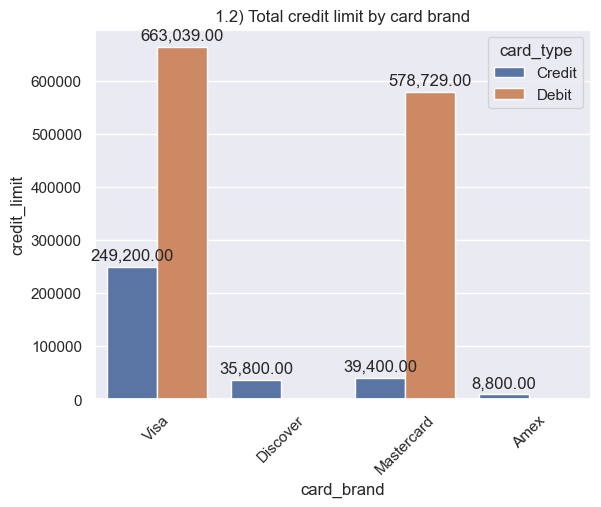

----------------------------------------------------------------------------------------------------


'1.3 Credit limits for Visa and Mastercard debit cards are amongst the highest which means that they allow more spending. Probably, we \nshould also aim to increase the credit limit/spending limit for VISA and Mastercards credit cards as well.'

In [10]:
#1.(a) Creating card_profile using and client_id, card_type and credit_limit  
card_profile = cards_data[['client_id','card_brand','card_type','credit_limit']]
card_profile = card_profile.groupby(['client_id','card_brand','card_type'])['credit_limit'].sum().reset_index()
print(f"1.1 Card Profile DataFrame :\n{card_profile.head()}")
print("--"*50)
#1.(b) Plotting the data to analyze credit_limit w.r.t card_brand for differenr card_type
sns.set_theme()
plt.figure()
ax = sns.barplot(data = card_profile,x = "card_brand",y="credit_limit",hue = "card_type",estimator = sum,errorbar = None)
for container in ax.containers:
    ax.bar_label(container,fmt='{:,.2f}', padding=3)

plt.title("1.2) Total credit limit by card brand")
plt.xticks(rotation =45)
plt.show()
print("--"*50)
#1.(c) Extract insights and recommend actions
"""1.3 Credit limits for Visa and Mastercard debit cards are amongst the highest which means that they allow more spending. Probably, we 
should also aim to increase the credit limit/spending limit for VISA and Mastercards credit cards as well."""

<h3>Explore Transactions</h3><a id = "5.2"></a>

2.1) Transactions time frame:2010-01-01 04:45:00 - 2012-10-29 12:55:00
----------------------------------------------------------------------------------------------------
2.2) Client that has spent the most amount :[['0708']] 
----------------------------------------------------------------------------------------------------
2.3) Highest transactions:6820.2 
Lowest transaction : -500.0
----------------------------------------------------------------------------------------------------
2.4) Transactions grouped by chip catgeory: {:,} use_chip
chip      1548188.57
online     438554.98
swipe      595250.17
Name: amount, dtype: float64
----------------------------------------------------------------------------------------------------


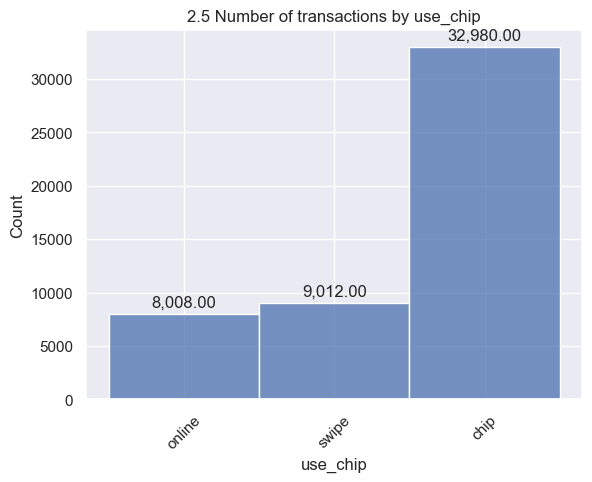

'The chip category has more transactions than the other two categories'

In [11]:
#2. Explore Transactions
#2.1 What is the time frame for transactions?
print(f"2.1) Transactions time frame:{trans_data['date'].min()} - {trans_data['date'].max()}")
print("--"*50)
#2.2 Which client has spent the most amount?
max_value_client = trans_data.loc[trans_data['amount'] == trans_data["amount"].max(),['client_id']]
print(f"2.2) Client that has spent the most amount :{max_value_client.values} ")
print("--"*50)
#2.3 Highest and lowest transactions amounts spent
print(f"2.3) Highest transactions:{trans_data['amount'].max()} \nLowest transaction : {trans_data['amount'].min()}")
print("--"*50)
#2.4 Transactions amounts within use_chip category

print("2.4) Transactions grouped by chip catgeory: {:,}",format(trans_data.groupby('use_chip')['amount'].sum()))
print("--"*50)
#2.5 Use appropriate Graphs and extract insights.
plt.figure()
ax = sns.histplot(data = trans_data,x ='use_chip')
for container in ax.containers:
    ax.bar_label(container,fmt = '{:,.2f}',padding =3)
plt.title("2.5 Number of transactions by use_chip")
plt.xticks(rotation = 45)
plt.show()
"""The chip category has more transactions than the other two categories"""

<h3>Customer Spend Profile</h3><a id = "5.3"></a>

3.1 DataFrame with total spend, average ticket size, transaction count, and monthly frequency for each client_id: 
  client_id  total_spent  avg_ticket_size  trans_count  active_months  \
0      0068    202013.82        57.098310         3538             34   
1      0153     70806.08        55.447204         1277             34   
2      0511    285794.61        43.646092         6548             34   
3      0708    326179.31       132.917404         2454             34   
4      0825    259484.68        81.088962         3200             34   

   monthly_freq  
0    104.058824  
1     37.558824  
2    192.588235  
3     72.176471  
4     94.117647  
----------------------------------------------------------------------------------------------------
3.2 DataFrame for credit_score, yearly_income, total_debt, num_credit_cards: 
  client_id  total_spent  avg_ticket_size  trans_count  active_months  \
0      0068    202013.82        57.098310         3538             34   
1      0153  

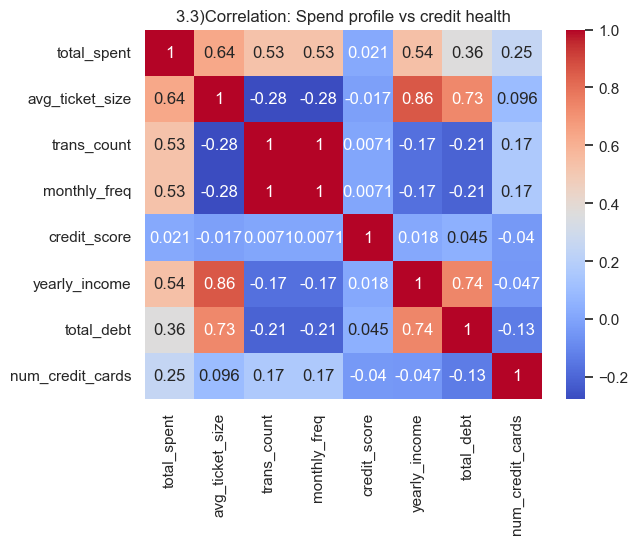

----------------------------------------------------------------------------------------------------


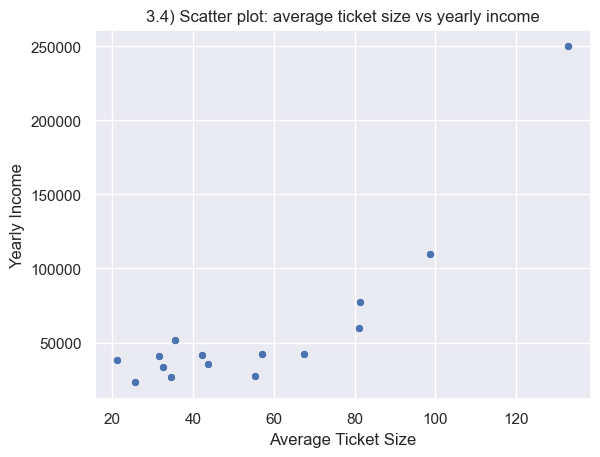

In [12]:
#3. Customer Spend Profile vs. Credit Health
#3.1 For each client_id, compute: total spend, average ticket size, transaction count, and monthly frequency.
trans_data['year_month'] = trans_data['date'].dt.to_period('M')
agg_trans = trans_data.groupby('client_id').agg(total_spent = ('amount','sum'),avg_ticket_size = ('amount','mean'),
                                                trans_count = ('id','count'),active_months = ('year_month','nunique')
                                               ).reset_index()
agg_trans['monthly_freq'] = agg_trans['trans_count']/agg_trans['active_months']
print(f"3.1 DataFrame with total spend, average ticket size, transaction count, and monthly frequency for each client_id: \n{agg_trans.head()}")
print("--"*50)
#3.2 Create a dataframe for credit_score, yearly_income, total_debt, num_credit_cards.
credit_health = users_data[['id','credit_score','yearly_income','total_debt','num_credit_cards']]
credit_health = credit_health.rename(columns = {'id':'client_id'})

client_profile = agg_trans.merge(credit_health,how = 'left', on = 'client_id')
print(f"3.2 DataFrame for credit_score, yearly_income, total_debt, num_credit_cards: \n{client_profile.head()}")
print("--"*50)
#3.3 Visualize their co-operation.
plt.figure()
cols = ["total_spent", "avg_ticket_size", "trans_count", "monthly_freq",
        "credit_score", "yearly_income", "total_debt", "num_credit_cards"]
sns.heatmap(client_profile[cols].corr(),annot = True,cmap = "coolwarm")
plt.title("3.3)Correlation: Spend profile vs credit health")
plt.show()
print("--"*50)
#3.4 Plot Scatter of average amount spent vs yearly_income.
plt.figure()
sns.scatterplot(data = client_profile, x = 'avg_ticket_size', y = 'yearly_income')
plt.title('3.4) Scatter plot: average ticket size vs yearly income')
plt.xlabel("Average Ticket Size")
plt.ylabel("Yearly Income")
plt.show()

<h3>Age Portfolio</h3><a id = "5.4"></a>

4.1) (a) Share of customers falling in each age band
age_band
Minor          2
Adult          8
Middle-Aged    8
Retired        7
Name: id_x, dtype: int64
4.1) (b) Average Credit limit by age band
age_band
Minor          171482.0
Adult          257259.0
Middle-Aged    383303.0
Retired        762924.0
Name: credit_limit, dtype: float64
----------------------------------------------------------------------------------------------------
4.2 Visualization for Age vs chip usage, income and credit score


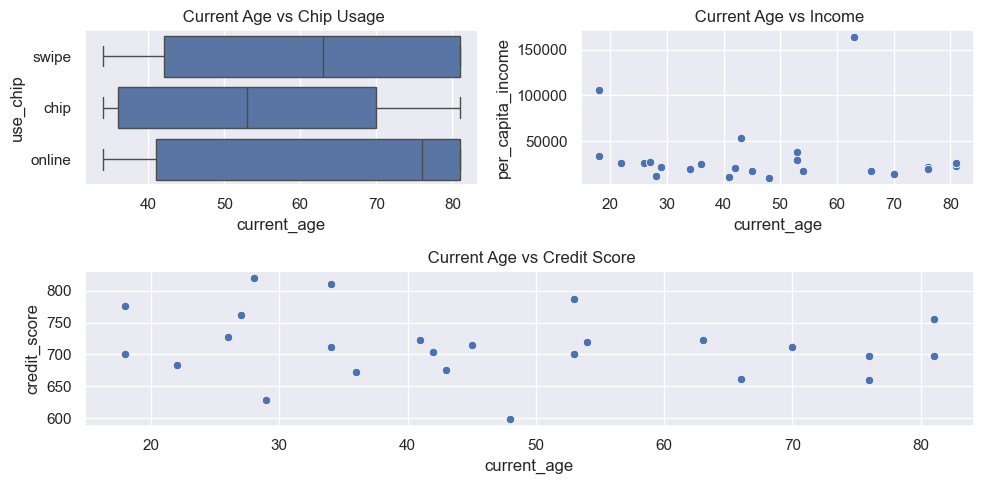

----------------------------------------------------------------------------------------------------
4.3 It seems from the data that the credit score and per_capita_income are fairly same for all age bands, but the credit limit for older generation is far more than the younger counterparts. Consequently, it would mena that the younger lot is not being allowed to spend more unnecessarily, therefore, we should allow more credit limit to the adult and middle-aged population.
----------------------------------------------------------------------------------------------------
4.4 It seems from the first box plot that old and retired people are buying more stuff online. 


In [13]:
#4 Age Portfolio
#4.1 Create appropriate age bands. What share of customers falls in each age band? How does the average credit_limit vary by band?
user_card = users_data.merge(cards_data,how = 'inner',left_on = 'id',right_on = 'client_id') 
#print(user_card.head())
bands = [0,18,40,60,100]
labels = ['Minor','Adult','Middle-Aged','Retired']
user_card['age_band'] = pd.cut(user_card['current_age'],bins = bands, labels = labels, include_lowest = True, ordered = False)
print("4.1) (a) Share of customers falling in each age band")
print(user_card.groupby('age_band',observed= False)['id_x'].nunique())
print("4.1) (b) Average Credit limit by age band")
print(user_card.groupby('age_band',observed= False)['credit_limit'].sum())
print("--"*50)
user_trans = users_data.merge(trans_data,how = 'inner',left_on = 'id',right_on = 'client_id') 
#print(user_trans.head())
#4.2 Visualize age vs chip_usage, income and credit score.
print("4.2 Visualization for Age vs chip usage, income and credit score")
fig = plt.figure(figsize = (10,5))
gs = fig.add_gridspec(2,2)

ax1 = fig.add_subplot(gs[0,0])
sns.boxplot(data = user_trans,x = 'current_age',y = 'use_chip',ax = ax1)
ax1.set_title(" Current Age vs Chip Usage")

ax2 = fig.add_subplot(gs[0,1])
sns.scatterplot(data = user_card,x = 'current_age',y = 'per_capita_income',ax = ax2)
ax2.set_title(" Current Age vs Income")

ax3 = fig.add_subplot(gs[1,:])
sns.scatterplot(data = user_card,x = 'current_age',y = 'credit_score',ax = ax3)
ax3.set_title(" Current Age vs Credit Score")

plt.tight_layout()
plt.show()
print("--"*50)

#4.3 Extract insights and recommend actions.
print("4.3 It seems from the data that the credit score and per_capita_income are fairly same for all age bands, but the credit limit for older \
generation is far more than the younger counterparts. Consequently, it would mena that the younger lot is not being allowed to spend more\
 unnecessarily, therefore, we should allow more credit limit to the adult and middle-aged population.")
print("--"*50)

#4.4 Are young customers online heavy?
print("4.4 It seems from the first box plot that old and retired people are buying more stuff online. ")


<h3>Gender Analysis</h3><a id ="5.5"></a>

5.1 Average transaction amount by gender: 
 gender
Female    51.678074
Male      51.573033
Name: amount, dtype: float64
----------------------------------------------------------------------------------------------------
5.2 Time-of-day / day-of-week profiles:
Time-of-day  Afternoon  Evening  Morning  Night
gender                                         
Female            9839     3070    15799   3109
Male              9245     1629     6680    629
Day-of-week  Weekday  Weekend
gender                       
Female         23127     8690
Male           13001     5182
----------------------------------------------------------------------------------------------------
5.3 Visualization transaction amount, time of day and day of week for males and females


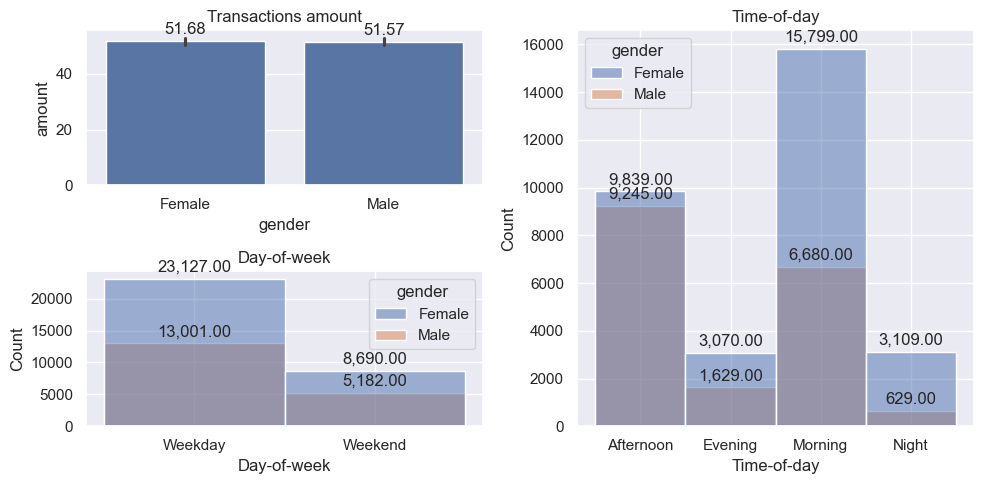

----------------------------------------------------------------------------------------------------


'5.4 The male and female average transaction amount seems to be the same at a high level. But there are significant differences \nbetween shopping patterns when we group them by time of day and day of week columns. We notice that females generally buy more \nduring evening, morning and night and especially during weekdays. So, we should run advertisement campaigns during weekdays from 8am -12am\n and 6pm-12pm to attarct more female customers.'

In [14]:
#5 Gender Analysis

#5(a) Avg transaction amount by gender.
user_trans = users_data.merge(trans_data,how = 'inner',left_on = 'id',right_on = 'client_id') 
print(f"5.1 Average transaction amount by gender: \n",user_trans.groupby('gender')['amount'].mean())
print("--"*50)
#5(b) Time-of-day / day-of-week profiles: does one group spend more at night/weekends?
bins = [0, 5, 12, 17, 21, 24]
labels = ['Night', 'Morning', 'Afternoon', 'Evening', 'Night']
user_trans['Time-of-day'] = pd.cut(user_trans['date'].dt.hour, bins=bins, labels=labels, include_lowest=True, ordered=False)
user_trans['Day-of-week'] = user_trans['date'].dt.dayofweek.apply(lambda x: "Weekend" if x>=5 else "Weekday")
print("5.2 Time-of-day / day-of-week profiles:")
print(pd.crosstab(user_trans['gender'],user_trans['Time-of-day']))
print(pd.crosstab(user_trans['gender'],user_trans['Day-of-week']))
print("--"*50)
#5.3 Visualize with appropriate graphs.
print("5.3 Visualization transaction amount, time of day and day of week for males and females")

fig = plt.figure(figsize = (10,5))
gs = fig.add_gridspec(2,2)

ax1 = fig.add_subplot(gs[0,0])
sns.barplot(data = user_trans,y = 'amount', x= 'gender',ax = ax1)
for container in ax1.containers:
    ax1.bar_label(container,fmt = '{:,.2f}',padding =3)
ax1.set_title("Transactions amount")

ax2 = fig.add_subplot(gs[:,1])
sns.histplot(data = user_trans,x = 'Time-of-day',hue = 'gender',ax= ax2)
for container in ax2.containers:
    ax2.bar_label(container,fmt = '{:,.2f}',padding =3)
ax2.set_title("Time-of-day")

ax3 = fig.add_subplot(gs[1,0])
sns.histplot(data = user_trans,x = 'Day-of-week',hue = 'gender',ax= ax3)
for container in ax3.containers:
    ax3.bar_label(container,fmt = '{:,.2f}',padding =3)
ax3.set_title("Day-of-week")

plt.tight_layout()
plt.show()
print("--"*50)

#5.4 Suggest marketing campaign ideas.
"""5.4 The male and female average transaction amount seems to be the same at a high level. But there are significant differences 
between shopping patterns when we group them by time of day and day of week columns. We notice that females generally buy more 
during evening, morning and night and especially during weekdays. So, we should run advertisement campaigns during weekdays from 8am -12am
 and 6pm-12pm to attarct more female customers."""
#user_trans.head()